In [40]:
# Cell 1: Import libraries and load the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

output_dir = Path("report_outputs")
output_dir.mkdir(exist_ok=True)

df = pd.read_csv("used_car_price_dataset_extended.csv")

df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [41]:
# Cell 2: Dataset inspection

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

df.info()

Dataset shape: (10000, 12)

Columns:
['make_year', 'mileage_kmpl', 'engine_cc', 'fuel_type', 'owner_count', 'price_usd', 'brand', 'transmission', 'color', 'service_history', 'accidents_reported', 'insurance_valid']

Data types:
make_year               int64
mileage_kmpl          float64
engine_cc               int64
fuel_type              object
owner_count             int64
price_usd             float64
brand                  object
transmission           object
color                  object
service_history        object
accidents_reported      int64
insurance_valid        object
dtype: object

Missing values:
make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

Duplicate rows:
0
<class 'pandas.core.frame

In [42]:
# Cell 3: Basic descriptive statistics

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

stats_table = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard deviation": df[numeric_columns].std(),
    "Maximum": df[numeric_columns].max(),
    "Minimum": df[numeric_columns].min()
}).round(3)

stats_table.to_csv(output_dir / "table_statistical_analysis.csv")

stats_table

,Mean,Median,Standard deviation,Maximum,Minimum
make_year,2009.207,2009.00,8.374,2023.00,1995.0
mileage_kmpl,17.961,17.97,5.025,35.00,5.0
engine_cc,2287.130,1800.00,1291.277,5000.00,800.0
owner_count,3.004,3.00,1.419,5.00,1.0
price_usd,7179.755,6961.26,2795.271,17647.63,1000.0
accidents_reported,0.492,0.00,0.694,5.00,0.0


In [43]:
# Cell 4: Correlation between numerical attributes and target variable

target_column = "price_usd"

correlation_table = df[numeric_columns].corr()[[target_column]].drop(target_column)
correlation_table = correlation_table.rename(columns={target_column: "Correlation coefficient"})
correlation_table = correlation_table.sort_values(by="Correlation coefficient", key=lambda x: abs(x), ascending=False).round(3)

correlation_table.to_csv(output_dir / "table_correlation_with_price.csv")

correlation_table

,Correlation coefficient
engine_cc,0.678
make_year,0.433
owner_count,-0.262
mileage_kmpl,0.212
accidents_reported,-0.001


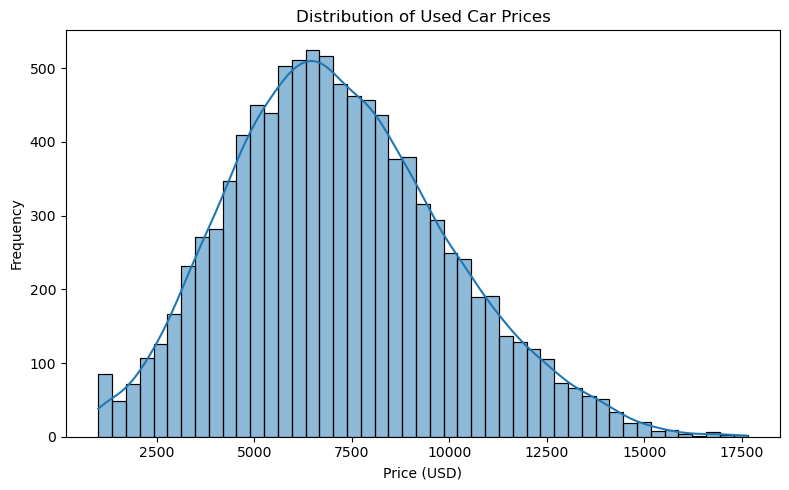

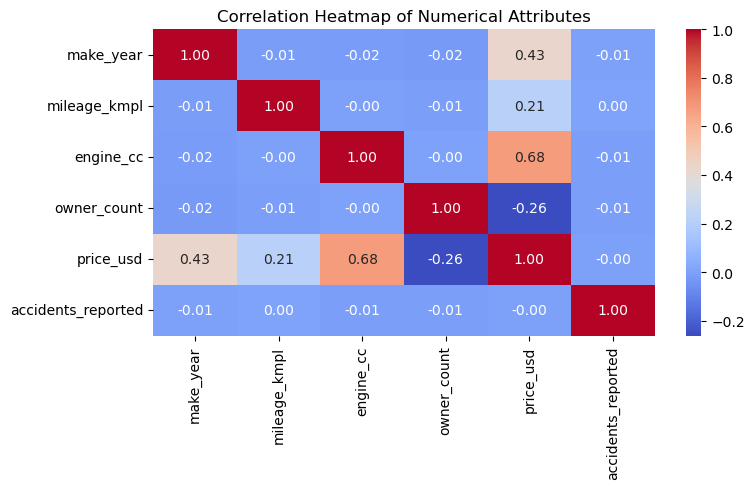

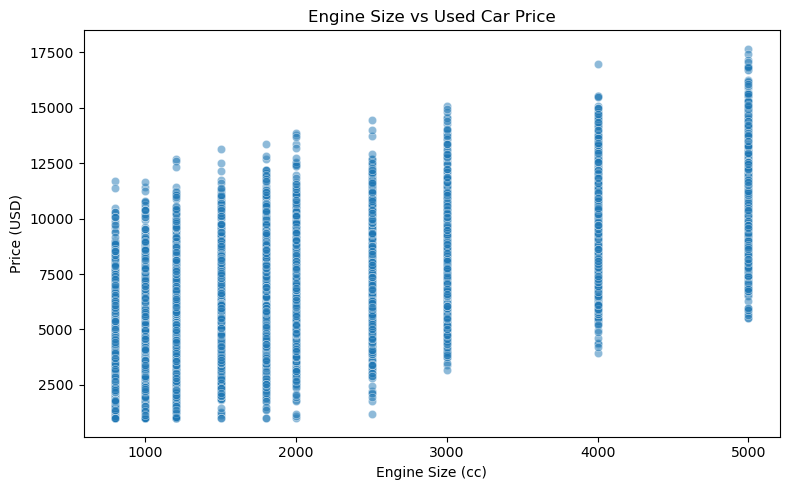

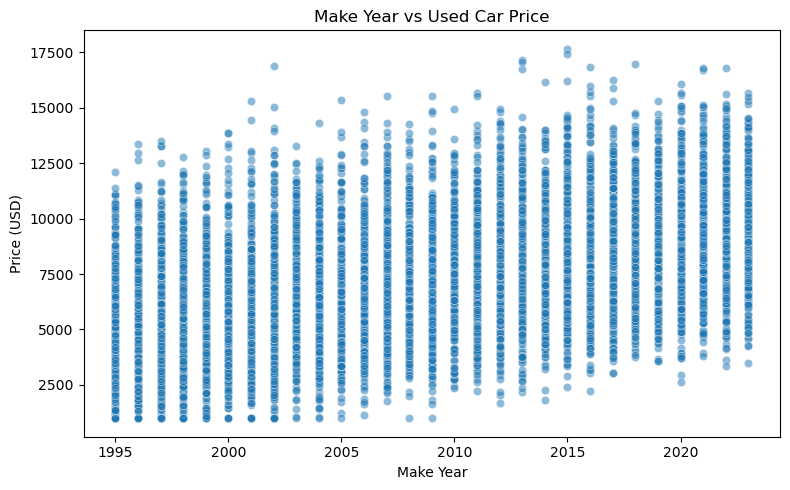

In [44]:
# Cell 5: Exploratory data analysis figures

plt.figure(figsize=(8, 5))
sns.histplot(df["price_usd"], kde=True)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(output_dir / "figure_price_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Attributes")
plt.tight_layout()
plt.savefig(output_dir / "figure_correlation_heatmap.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="engine_cc", y="price_usd", alpha=0.5)
plt.title("Engine Size vs Used Car Price")
plt.xlabel("Engine Size (cc)")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.savefig(output_dir / "figure_engine_vs_price.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="make_year", y="price_usd", alpha=0.5)
plt.title("Make Year vs Used Car Price")
plt.xlabel("Make Year")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.savefig(output_dir / "figure_year_vs_price.png", dpi=300)
plt.show()

In [45]:
# Cell 6: Data preprocessing
# Numerical features are scaled for Linear Regression, and categorical features are converted into numerical form using One-Hot Encoding.

df_model = df.copy()

df_model = df_model.drop_duplicates()

X = df_model.drop(columns=[target_column])
y = df_model[target_column]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Numerical features: ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']
Categorical features: ['fuel_type', 'brand', 'transmission', 'color', 'service_history', 'insurance_valid']


In [46]:
# Cell 7: Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8000, 11)
Testing set size: (2000, 11)


In [47]:
# Cell 8: Define models and evaluation function

linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", LinearRegression())
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ]
)

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }

In [48]:
# Cell 9: Train and evaluate the initial models using all features

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

initial_results = pd.DataFrame([
    evaluate_model("Linear Regression", linear_model, X_test, y_test),
    evaluate_model("Random Forest Regression", rf_model, X_test, y_test)
])

initial_results_rounded = initial_results.copy()
initial_results_rounded[["MAE", "MSE", "RMSE", "R²"]] = initial_results_rounded[["MAE", "MSE", "RMSE", "R²"]].round(4)

initial_results_rounded.to_csv(output_dir / "table_initial_model_results.csv", index=False)

initial_results_rounded

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,791.0024,9.821137e+05,991.0165,0.8765
1,Random Forest Regression,864.8788,1.178397e+06,1085.5402,0.8519


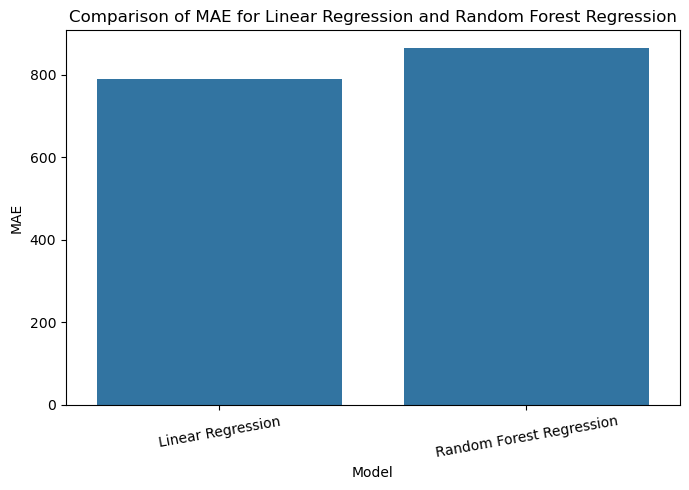

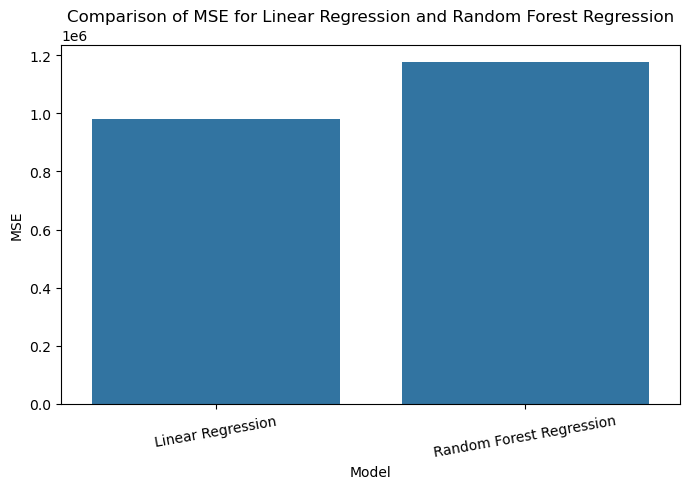

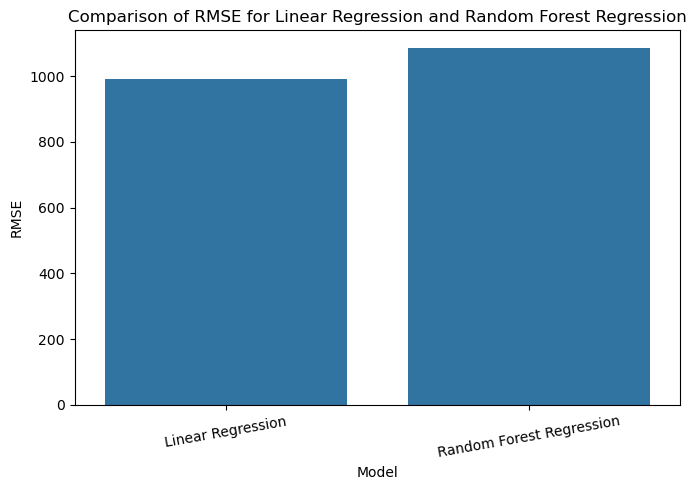

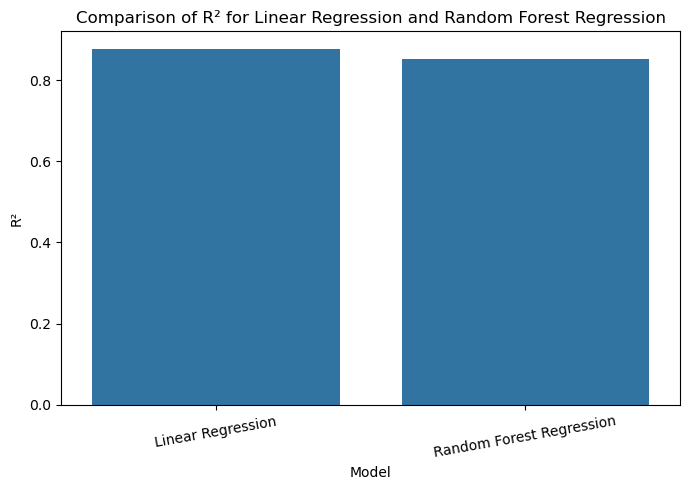

In [49]:
# Cell 10: Initial model comparison figures

metrics_to_plot = ["MAE", "MSE", "RMSE", "R²"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))
    sns.barplot(data=initial_results, x="Model", y=metric)
    plt.title(f"Comparison of {metric} for Linear Regression and Random Forest Regression")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.savefig(output_dir / f"figure_initial_comparison_{metric}.png", dpi=300)
    plt.show()

In [50]:
# Cell 11: Individual hyperparameter analysis for Random Forest

def evaluate_rf_parameter(parameter_name, parameter_values):
    results = []
    
    for value in parameter_values:
        rf = Pipeline(
            steps=[
                ("preprocessor", rf_preprocessor),
                ("model", RandomForestRegressor(
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    **{parameter_name: value}
                ))
            ]
        )
        
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        results.append({
            "Parameter": parameter_name,
            "Value": str(value),
            "RMSE": rmse,
            "R²": r2
        })
    
    return pd.DataFrame(results)

n_estimators_results = evaluate_rf_parameter("n_estimators", [50, 100, 150, 200, 300])
max_depth_results = evaluate_rf_parameter("max_depth", [5, 10, 15, 20, 25, None])
min_samples_split_results = evaluate_rf_parameter("min_samples_split", [2, 5, 10, 15, 20])
min_samples_leaf_results = evaluate_rf_parameter("min_samples_leaf", [1, 2, 4, 6, 8])

tuning_plot_results = pd.concat([
    n_estimators_results,
    max_depth_results,
    min_samples_split_results,
    min_samples_leaf_results
], ignore_index=True)

tuning_plot_results.to_csv(output_dir / "table_hyperparameter_search_plot_results.csv", index=False)

tuning_plot_results

,Parameter,Value,RMSE,R²
0,n_estimators,50,1091.740912,0.850180
1,n_estimators,100,1085.540163,0.851877
2,n_estimators,150,1084.268339,0.852224
3,n_estimators,200,1083.342878,0.852476
4,n_estimators,300,1084.074276,0.852277
5,max_depth,5,1369.891230,0.764113
6,max_depth,10,1074.070466,0.854990
7,max_depth,15,1084.326344,0.852208
8,max_depth,20,1084.726937,0.852099
9,max_depth,25,1086.407543,0.851640


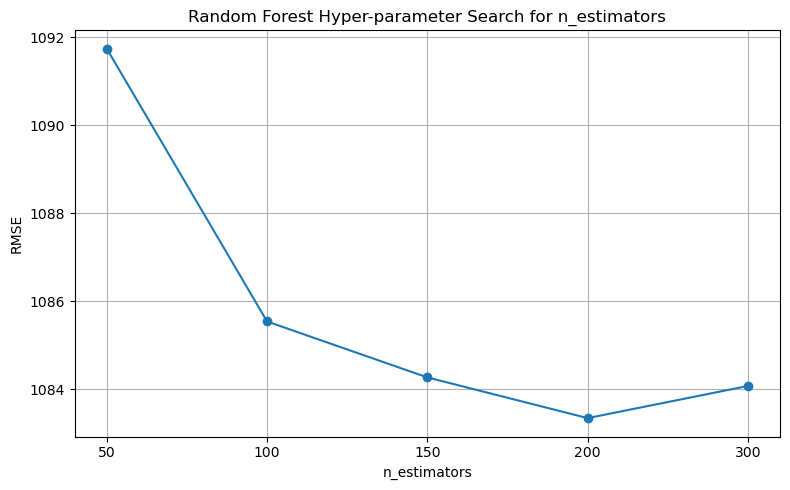

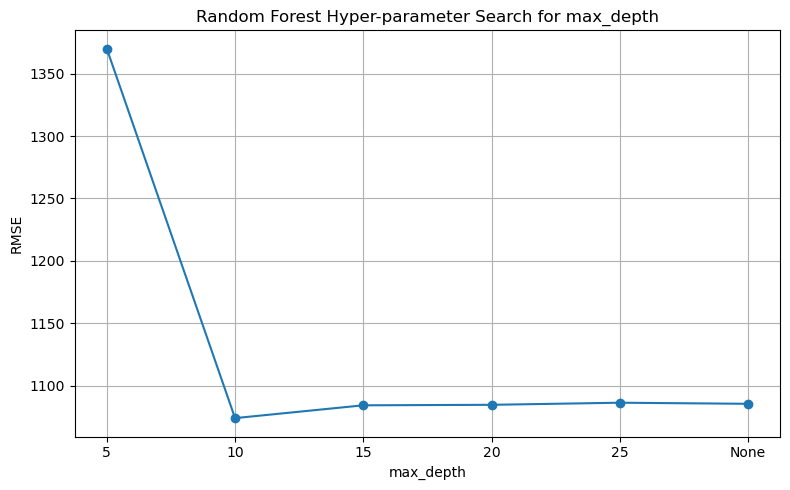

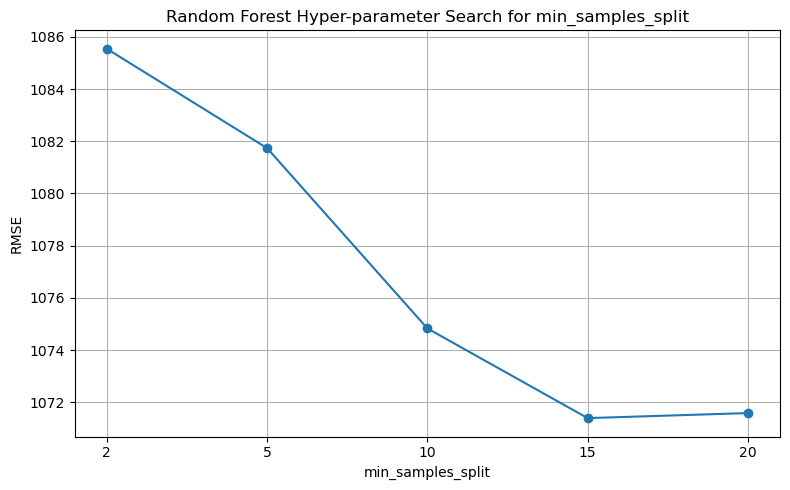

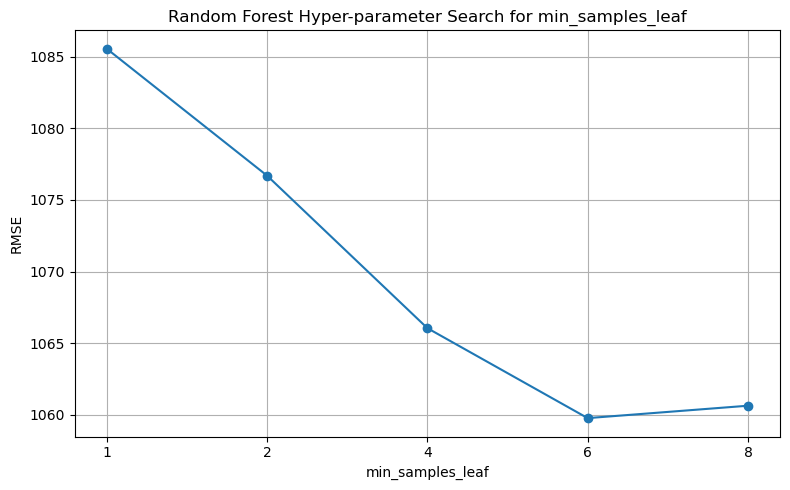

In [51]:
# Cell 12: Generate hyperparameter tuning diagrams

def plot_parameter_search(results_df, parameter_name, figure_name):
    data = results_df[results_df["Parameter"] == parameter_name].copy()
    
    plt.figure(figsize=(8, 5))
    plt.plot(data["Value"], data["RMSE"], marker="o")
    plt.title(f"Random Forest Hyper-parameter Search for {parameter_name}")
    plt.xlabel(parameter_name)
    plt.ylabel("RMSE")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_dir / figure_name, dpi=300)
    plt.show()

plot_parameter_search(tuning_plot_results, "n_estimators", "figure_rf_tuning_n_estimators.png")
plot_parameter_search(tuning_plot_results, "max_depth", "figure_rf_tuning_max_depth.png")
plot_parameter_search(tuning_plot_results, "min_samples_split", "figure_rf_tuning_min_samples_split.png")
plot_parameter_search(tuning_plot_results, "min_samples_leaf", "figure_rf_tuning_min_samples_leaf.png")

In [52]:
# Cell 13: Deifining Random Forest model using the best values from the individual hyperparameter analysis

best_rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_split=15,
            min_samples_leaf=6,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

best_rf_model.fit(X_train, y_train)

tuned_rf_results = pd.DataFrame([
    evaluate_model("Tuned Random Forest Regression", best_rf_model, X_test, y_test)
])

tuned_rf_results_rounded = tuned_rf_results.copy()
tuned_rf_results_rounded[["MAE", "MSE", "RMSE", "R²"]] = tuned_rf_results_rounded[["MAE", "MSE", "RMSE", "R²"]].round(4)

tuned_rf_results_rounded

,Model,MAE,MSE,RMSE,R²
0,Tuned Random Forest Regression,844.8639,1.127545e+06,1061.8593,0.8583


In [53]:
# Additional hyperparameter search using RandomizedSearchCV. This step tests random combinations of Random Forest parameters using cross-validation.
# It is kept as an additional comparison, because the results from individual hyperparameter analysis are better so they are used for the final model

rf_pipeline_for_search = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ]
)

param_distributions = {
    "model__n_estimators": [50, 100, 150, 200, 300],
    "model__max_depth": [5, 10, 15, 20, 25, None],
    "model__min_samples_split": [2, 5, 10, 15, 20],
    "model__min_samples_leaf": [1, 2, 4, 6, 8],
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline_for_search,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

random_search_rf_model = random_search.best_estimator_
random_search_rf_params = random_search.best_params_

random_search_params_table = pd.DataFrame({
    "Parameter": [key.replace("model__", "") for key in random_search_rf_params.keys()],
    "RandomizedSearchCV Value": [str(value) for value in random_search_rf_params.values()]
})

print("Best RandomizedSearchCV CV RMSE:", -random_search.best_score_)

random_search_params_table

Best RandomizedSearchCV CV RMSE: 1074.190597124229


,Parameter,RandomizedSearchCV Value
0,n_estimators,100
1,min_samples_split,10
2,min_samples_leaf,4
3,max_features,None
4,max_depth,10


In [54]:
# Cell 14: Evaluate tuned Random Forest against baseline models (Note: Linear Regression doesnt need tuning)

tuned_results = pd.DataFrame([
    evaluate_model("Linear Regression", linear_model, X_test, y_test),
    evaluate_model("Random Forest Regression", rf_model, X_test, y_test),
    evaluate_model("Tuned Random Forest Regression", best_rf_model, X_test, y_test)
])

tuned_results_rounded = tuned_results.copy()
tuned_results_rounded[["MAE", "MSE", "RMSE", "R²"]] = tuned_results_rounded[["MAE", "MSE", "RMSE", "R²"]].round(4)

tuned_results_rounded.to_csv(output_dir / "table_tuned_model_results.csv", index=False)

tuned_results_rounded

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,791.0024,9.821137e+05,991.0165,0.8765
1,Random Forest Regression,864.8788,1.178397e+06,1085.5402,0.8519
2,Tuned Random Forest Regression,844.8639,1.127545e+06,1061.8593,0.8583


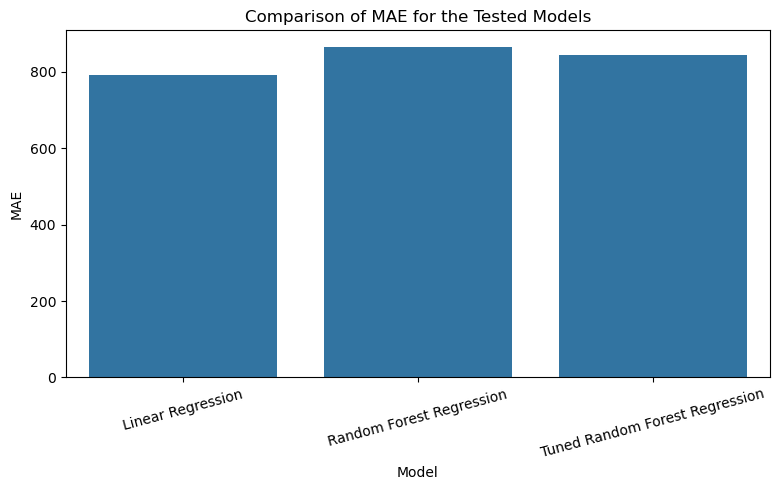

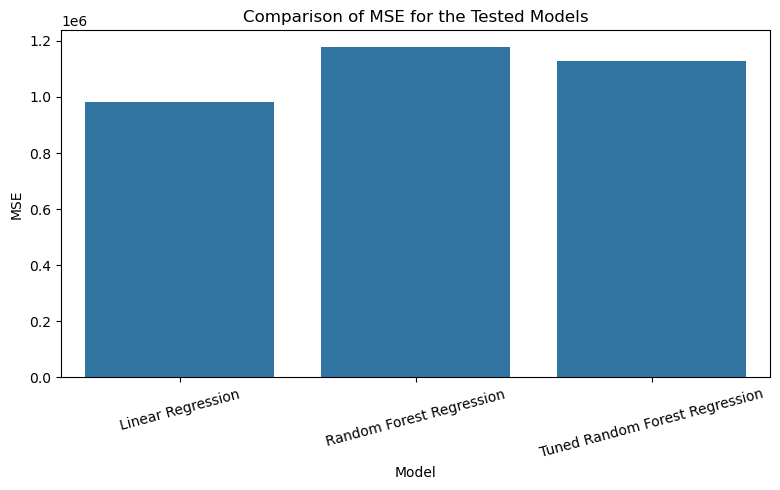

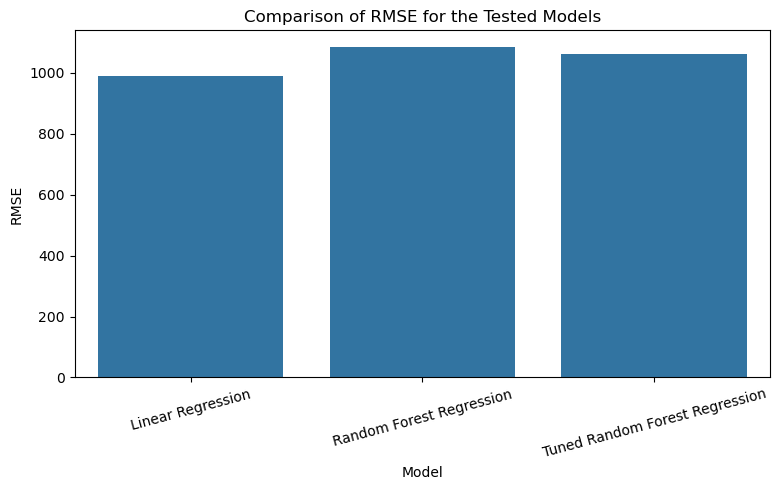

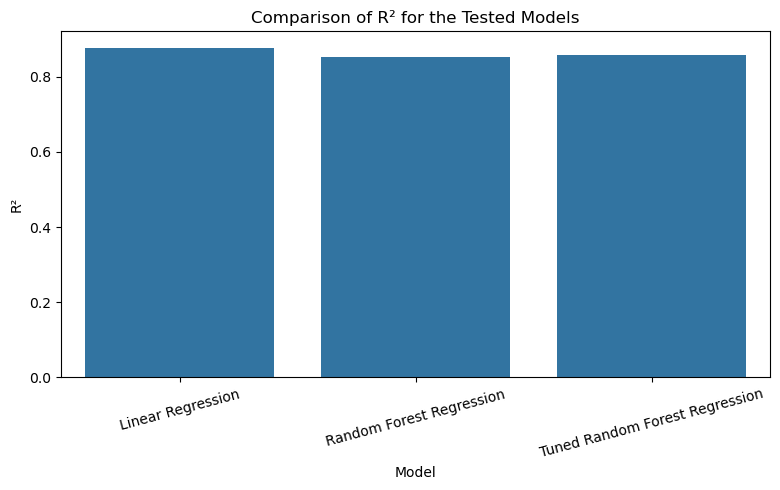

In [55]:
# Cell 15: Tuned model comparison figures

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=tuned_results, x="Model", y=metric)
    plt.title(f"Comparison of {metric} for the Tested Models")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(output_dir / f"figure_tuned_comparison_{metric}.png", dpi=300)
    plt.show()

In [56]:
# Cell 16: Prepare encoded data for feature selection

feature_selection_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_encoded = feature_selection_preprocessor.fit_transform(X)

encoded_feature_names = feature_selection_preprocessor.get_feature_names_out()
encoded_feature_names = [name.replace("num__", "").replace("cat__", "") for name in encoded_feature_names]

if hasattr(X_encoded, "toarray"):
    X_encoded = X_encoded.toarray()

X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_feature_names)

X_encoded_df.head()

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,brand_BMW,brand_Chevrolet,...,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Full,service_history_Partial,service_history_nan,insurance_valid_No,insurance_valid_Yes
0,-0.980111,-1.948317,1.326559,0.702338,-0.709146,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1,0.572417,-0.073778,-0.609605,0.702338,-0.709146,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,1.647244,0.025720,0.164861,1.407142,0.731622,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.024709,-1.329441,-1.151732,-1.412076,-0.709146,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.502410,-1.140395,-0.996838,-0.707271,-0.709146,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [57]:
# Cell 17: Rank features by correlation with the target variable

feature_correlations = X_encoded_df.apply(lambda col: np.corrcoef(col, y)[0, 1])
feature_correlations = feature_correlations.replace([np.inf, -np.inf], np.nan).fillna(0)

feature_ranking = pd.DataFrame({
    "Feature": feature_correlations.index,
    "Correlation with price_usd": feature_correlations.values,
    "Absolute Correlation": np.abs(feature_correlations.values)
}).sort_values(by="Absolute Correlation", ascending=False)

feature_ranking.to_csv(output_dir / "table_feature_correlation_ranking.csv", index=False)

feature_ranking.head(20)

,Feature,Correlation with price_usd,Absolute Correlation
2,engine_cc,0.678161,0.678161
0,make_year,0.432603,0.432603
6,fuel_type_Electric,0.312584,0.312584
3,owner_count,-0.262266,0.262266
1,mileage_kmpl,0.211971,0.211971
7,fuel_type_Petrol,-0.106382,0.106382
5,fuel_type_Diesel,-0.080423,0.080423
24,color_Silver,-0.023013,0.023013
23,color_Red,0.017251,0.017251
8,brand_BMW,0.016295,0.016295


In [58]:
# Cell 18: Feature selection experiment

ranked_features = feature_ranking["Feature"].tolist()

feature_subset_sizes = []
current_size = len(ranked_features)

while current_size >= 1:
    feature_subset_sizes.append(current_size)
    current_size = current_size // 2

feature_subset_sizes = sorted(list(set(feature_subset_sizes)), reverse=True)

cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

feature_selection_results = []

for size in feature_subset_sizes:
    selected_features = ranked_features[:size]
    X_subset = X_encoded_df[selected_features]
    
    lr = LinearRegression()
    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=200,
        max_depth=10,
        min_samples_split=15,
        min_samples_leaf=6,
        max_features=None
    )
    
    lr_scores = cross_validate(
        lr,
        X_subset,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )
    
    rf_scores = cross_validate(
        rf,
        X_subset,
        y,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )
    
    feature_selection_results.append({
        "Feature subset": f"Best {size} features",
        "Number of features": size,
        "Linear Regression MAE": -lr_scores["test_MAE"].mean(),
        "Linear Regression RMSE": -lr_scores["test_RMSE"].mean(),
        "Linear Regression R²": lr_scores["test_R2"].mean(),
        "Random Forest MAE": -rf_scores["test_MAE"].mean(),
        "Random Forest RMSE": -rf_scores["test_RMSE"].mean(),
        "Random Forest R²": rf_scores["test_R2"].mean()
    })

feature_selection_results = pd.DataFrame(feature_selection_results)

feature_selection_results_rounded = feature_selection_results.copy()
numeric_result_columns = feature_selection_results_rounded.select_dtypes(include=["float64"]).columns
feature_selection_results_rounded[numeric_result_columns] = feature_selection_results_rounded[numeric_result_columns].round(4)

feature_selection_results_rounded.to_csv(output_dir / "table_feature_selection_results.csv", index=False)

feature_selection_results_rounded

,Feature subset,Number of features,Linear Regression MAE,Linear Regression RMSE,Linear Regression R²,Random Forest MAE,Random Forest RMSE,Random Forest R²
0,Best 31 features,31,797.7702,1002.1342,0.8710,847.6334,1064.8199,0.8544
1,Best 15 features,15,797.4538,1001.4526,0.8712,844.6942,1061.0626,0.8554
2,Best 7 features,7,797.4616,1001.1244,0.8713,843.0373,1058.8679,0.8560
3,Best 3 features,3,1093.9651,1363.6681,0.7613,1110.6909,1387.8416,0.7526
4,Best 1 features,1,1646.5324,2054.4733,0.4584,1647.8288,2055.4998,0.4579


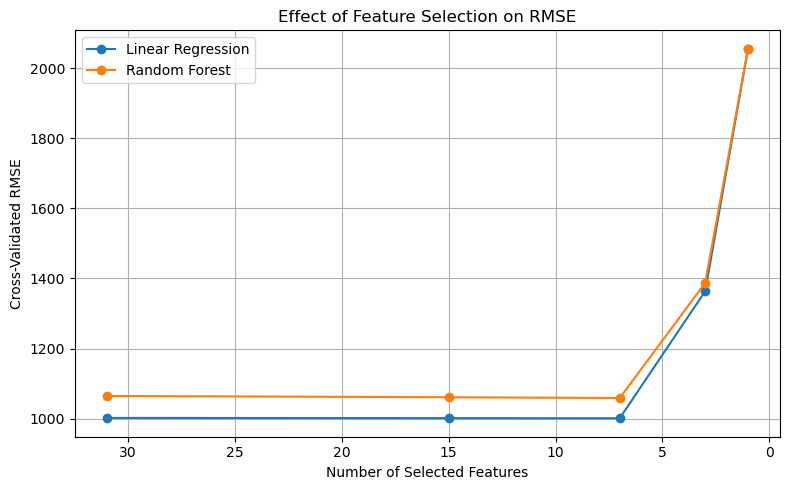

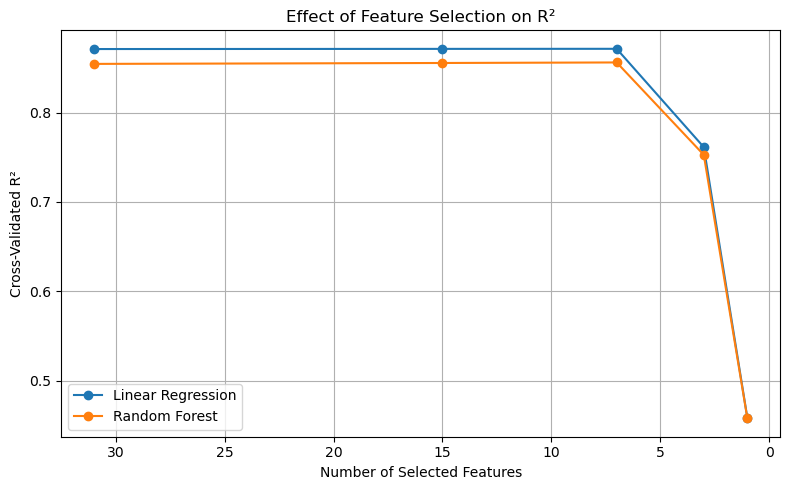

In [59]:
# Cell 19: Feature selection performance plots

plt.figure(figsize=(8, 5))
plt.plot(feature_selection_results["Number of features"], feature_selection_results["Linear Regression RMSE"], marker="o", label="Linear Regression")
plt.plot(feature_selection_results["Number of features"], feature_selection_results["Random Forest RMSE"], marker="o", label="Random Forest")
plt.title("Effect of Feature Selection on RMSE")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated RMSE")
plt.gca().invert_xaxis()
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "figure_feature_selection_rmse.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(feature_selection_results["Number of features"], feature_selection_results["Linear Regression R²"], marker="o", label="Linear Regression")
plt.plot(feature_selection_results["Number of features"], feature_selection_results["Random Forest R²"], marker="o", label="Random Forest")
plt.title("Effect of Feature Selection on R²")
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated R²")
plt.gca().invert_xaxis()
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "figure_feature_selection_r2.png", dpi=300)
plt.show()

In [60]:
# Cell 20: Choose the best feature subset

best_feature_selection_row = feature_selection_results.loc[feature_selection_results["Random Forest RMSE"].idxmin()]
best_number_of_features = int(best_feature_selection_row["Number of features"])
best_selected_features = ranked_features[:best_number_of_features]

best_features_table = pd.DataFrame({
    "Selected Feature": best_selected_features
})

best_features_table.to_csv(output_dir / "table_best_selected_features.csv", index=False)

print("Best number of features:", best_number_of_features)
best_features_table

Best number of features: 7


,Selected Feature
0,engine_cc
1,make_year
2,fuel_type_Electric
3,owner_count
4,mileage_kmpl
5,fuel_type_Petrol
6,fuel_type_Diesel


In [61]:
# Cell 21: Train final models using the best selected features

X_train_encoded = feature_selection_preprocessor.transform(X_train)
X_test_encoded = feature_selection_preprocessor.transform(X_test)

if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()

if hasattr(X_test_encoded, "toarray"):
    X_test_encoded = X_test_encoded.toarray()

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names)

X_train_best = X_train_encoded_df[best_selected_features]
X_test_best = X_test_encoded_df[best_selected_features]

final_lr = LinearRegression()

final_rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_estimators=200,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=6,
    max_features=None
)

final_lr.fit(X_train_best, y_train)
final_rf.fit(X_train_best, y_train)

def evaluate_direct_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    
    mae = mean_absolute_error(y_test_data, y_pred)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }

final_results = pd.DataFrame([
    evaluate_direct_model("Final Linear Regression", final_lr, X_test_best, y_test),
    evaluate_direct_model("Final Random Forest Regression", final_rf, X_test_best, y_test)
])

final_results_rounded = final_results.copy()
final_results_rounded[["MAE", "MSE", "RMSE", "R²"]] = final_results_rounded[["MAE", "MSE", "RMSE", "R²"]].round(4)

final_results_rounded.to_csv(output_dir / "table_final_model_results.csv", index=False)

final_results_rounded

,Model,MAE,MSE,RMSE,R²
0,Final Linear Regression,791.3660,9.812410e+05,990.5761,0.8767
1,Final Random Forest Regression,840.2787,1.114687e+06,1055.7874,0.8599


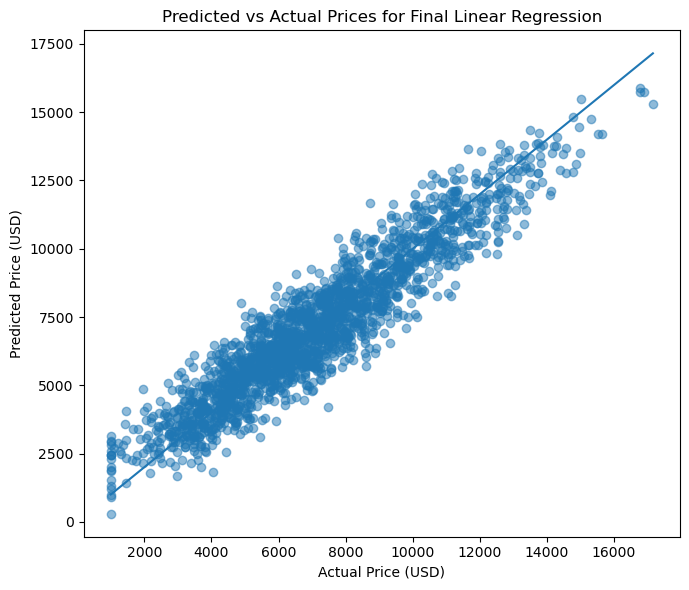

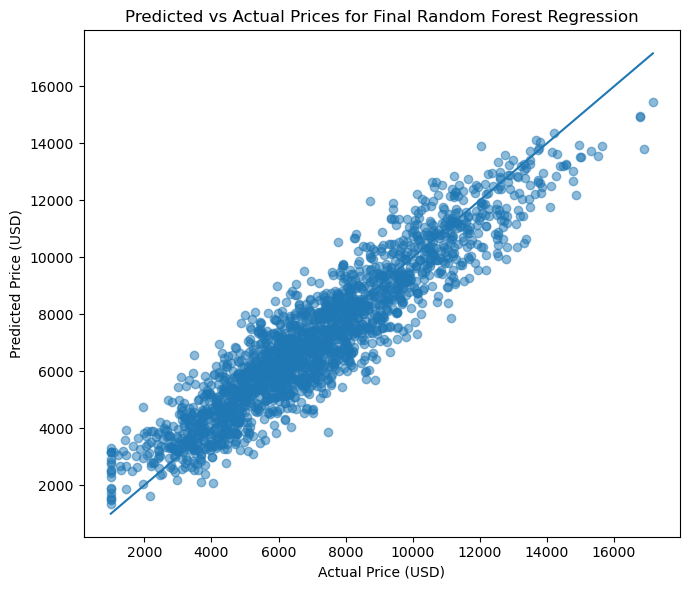

In [62]:
# Cell 22: Predicted vs actual plots for final models

final_lr_predictions = final_lr.predict(X_test_best)
final_rf_predictions = final_rf.predict(X_test_best)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_lr_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Predicted vs Actual Prices for Final Linear Regression")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.tight_layout()
plt.savefig(output_dir / "figure_predicted_vs_actual_linear_regression.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_rf_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Predicted vs Actual Prices for Final Random Forest Regression")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.tight_layout()
plt.savefig(output_dir / "figure_predicted_vs_actual_random_forest.png", dpi=300)
plt.show()

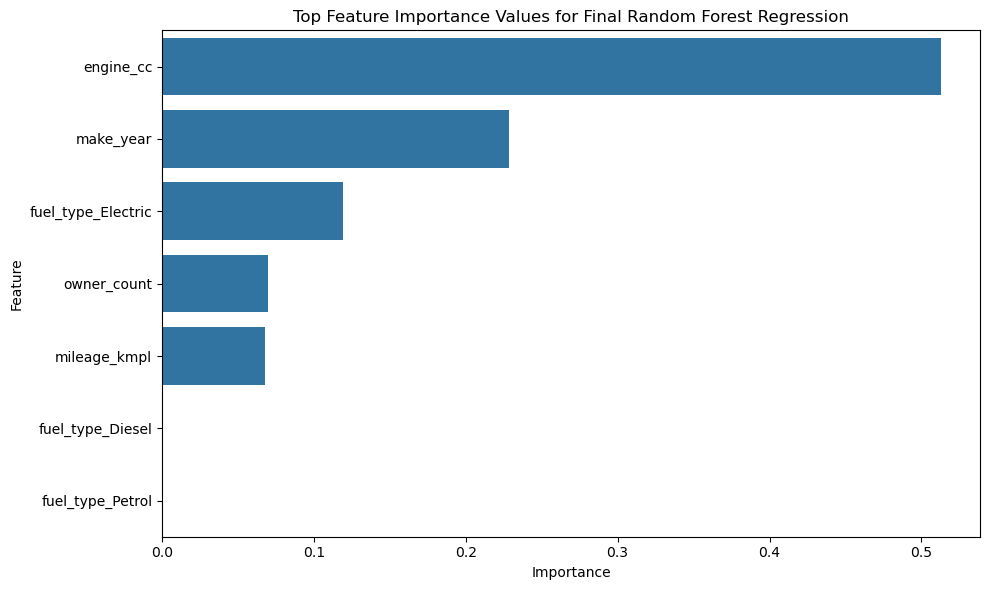

,Feature,Importance
0,engine_cc,0.512929
1,make_year,0.228638
2,fuel_type_Electric,0.118843
3,owner_count,0.070059
4,mileage_kmpl,0.067984
6,fuel_type_Diesel,0.000815
5,fuel_type_Petrol,0.000732


In [65]:
# Cell 23: Feature importance for the final Random Forest model.

rf_importance = pd.DataFrame({
    "Feature": best_selected_features,
    "Importance": final_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance.to_csv(output_dir / "table_random_forest_feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance.head(15), x="Importance", y="Feature")
plt.title("Top Feature Importance Values for Final Random Forest Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(output_dir / "figure_random_forest_feature_importance.png", dpi=300)
plt.show()

rf_importance.head(15)

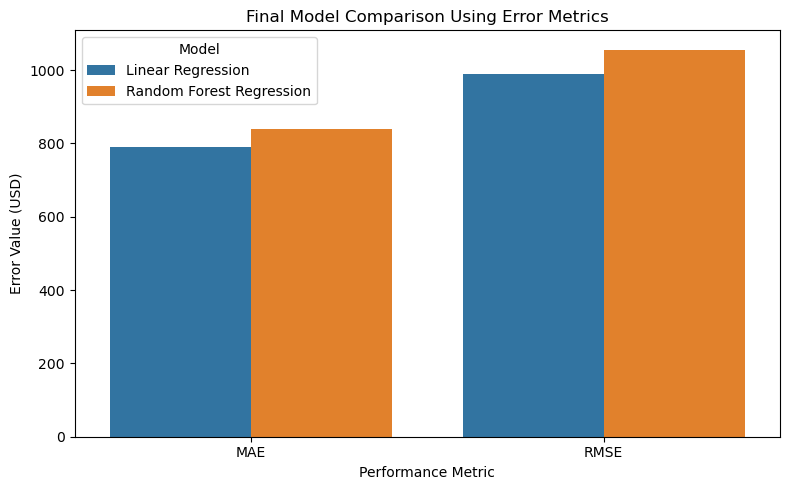

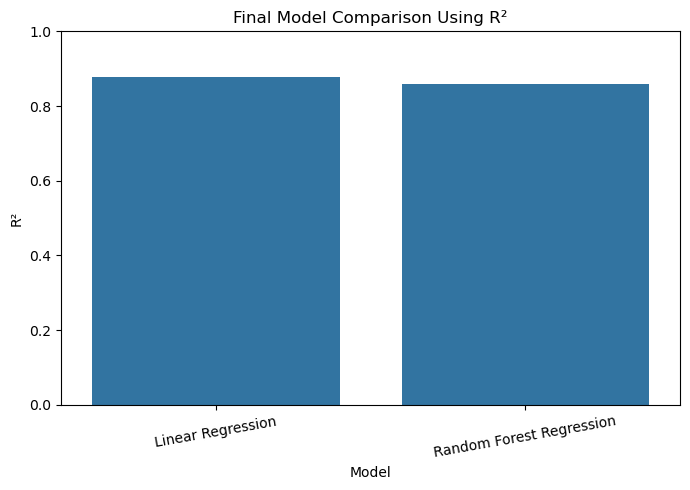

In [68]:
# Cell 24: Final comparison figures

plot_results = final_results.copy()
plot_results["Model"] = plot_results["Model"].replace({
    "Final Linear Regression": "Linear Regression",
    "Final Random Forest Regression": "Random Forest Regression"
})

error_metrics = plot_results.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=error_metrics, x="Metric", y="Value", hue="Model")
plt.title("Final Model Comparison Using Error Metrics")
plt.xlabel("Performance Metric")
plt.ylabel("Error Value (USD)")
plt.tight_layout()
plt.savefig(output_dir / "figure_final_error_metrics_comparison.png", dpi=300)
plt.show()

r2_data = plot_results[["Model", "R²"]].copy()

plt.figure(figsize=(7, 5))
sns.barplot(data=r2_data, x="Model", y="R²")
plt.title("Final Model Comparison Using R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(output_dir / "figure_final_r2_comparison.png", dpi=300)
plt.show()